In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *

from netmap.downstream.markers import *
import scipy.sparse as scs


import numpy as np
from pathlib import Path


In [2]:
pangalao_markers = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/PanglaoDB_markers_27_Mar_2020.tsv', sep  = '\t')
cellmarker = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/Cell_marker_Seq.csv', sep ='\t')
cluster_assignment = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/celltype_clustering.tsv', sep = '\t')


In [3]:
experiment_name = 'bd-rhap-rep1-X'
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"
adata_raw = sc.read_h5ad(f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/bd-rhap-rep1/bd-rhap-rep1.h5ad')



In [4]:
grn_adata3 = sc.read_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
all_signatures = sc.read_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

In [5]:
all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values

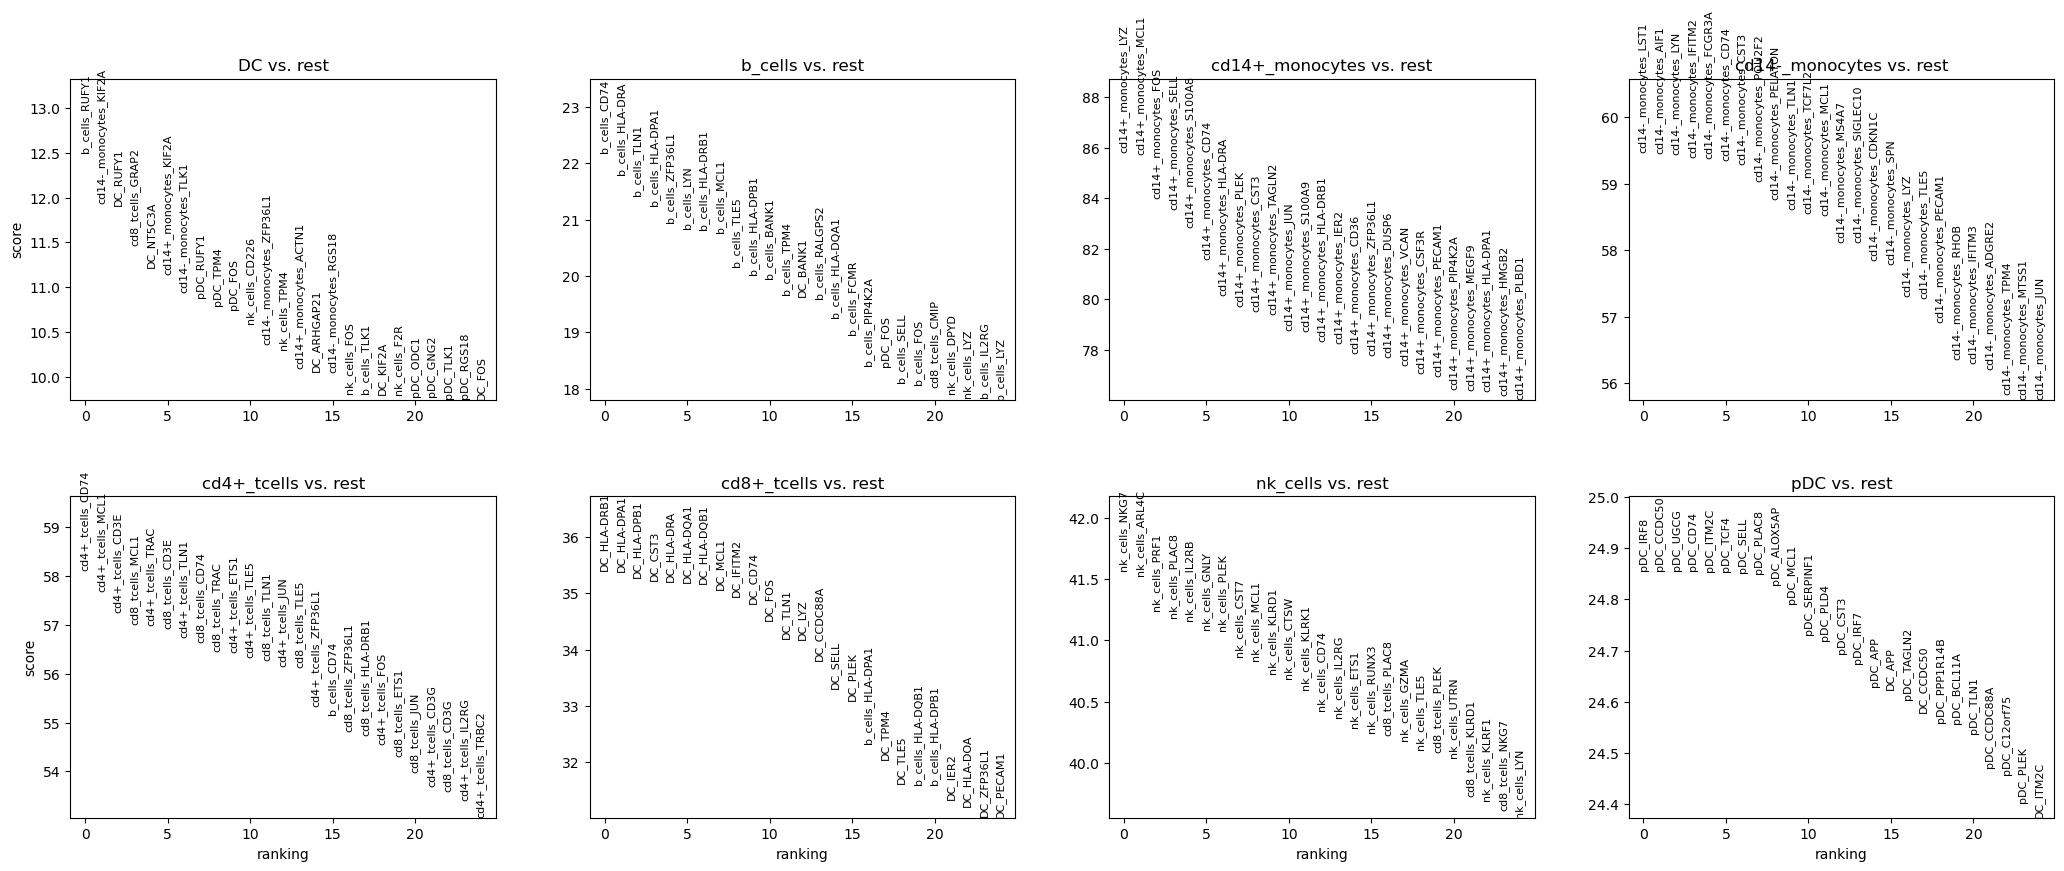

In [6]:
cluster_column = 'leiden_remap'
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(all_signatures, n_genes=25, sharey=False, key="wilcoxon")

In [7]:
top_per_source = 10
cluster_column = 'leiden_remap'
min_reg_size = 1
keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=top_per_source, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True)


Selecting targets for cluster: DC


Selecting targets for cluster: b_cells
Selecting targets for cluster: cd14+_monocytes
Selecting targets for cluster: cd14-_monocytes
Selecting targets for cluster: cd4+_tcells
Selecting targets for cluster: cd8+_tcells
Selecting targets for cluster: nk_cells
Selecting targets for cluster: pDC


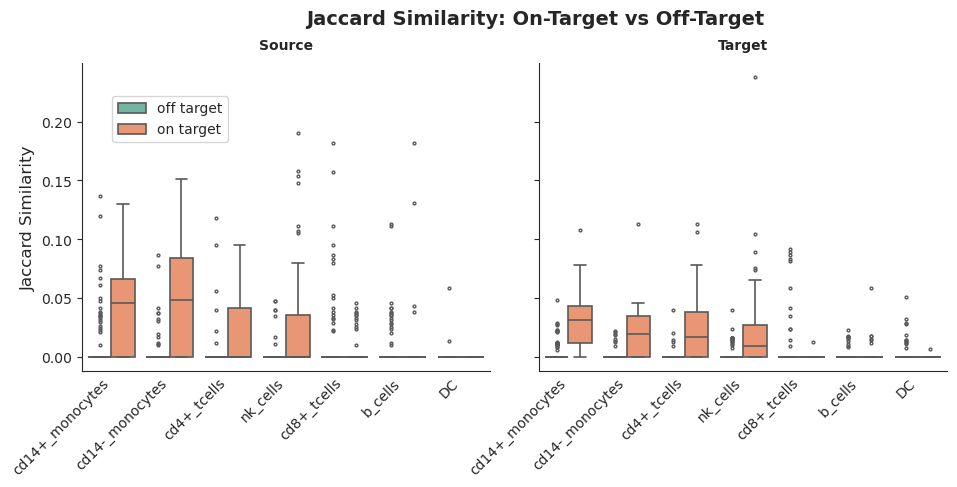

In [10]:
cluster_mapper = {'b_cells': ['B cells', 'B cells/ Dendritic cells'], 'cd14+_monocytes': ['Monocytes'], 'cd14-_monocytes': ['Monocytes'], 'cd4+_tcells': ['T cells', 'T cells/ NK cells'], 'nk_cells': ['T cells', 'T cells/ NK cells'],
 'DC':['B cells/ Dendritic cells'], 'cd8+_tcells': ['T cells', 'T cells/ NK cells']}

cm_filtered = cellmarker[
    (cellmarker.tissue_type.isin(['Peripheral blood', 'Blood'])) & 
    (cellmarker.species == 'Human')
]
marker_sets = cm_filtered.groupby('cell_name')['marker'].apply(set).to_dict()




# 2. Run the processing
jaccard_data = prepare_jaccard_analysis_df(grn_adata3, all_signatures, keep_edges, marker_sets,  cluster_mapper)


# Merge with cluster metadata
jaccard_data = jaccard_data.merge(cluster_assignment, left_on='celltype', right_on='index')

# Mapping Logic (On-Target vs Off-Target)
def check_match(row):
    allowed = cluster_mapper.get(row['ct'], [])
    return 'on target' if row['cluster_high_level'] in allowed else 'off target'

jaccard_data['is_mapped'] = jaccard_data.apply(check_match, axis=1)
jaccard_data = jaccard_data[jaccard_data['ct'].isin(cluster_mapper.keys())].copy()

jaccard_data['database'] = 'cell_marker'

# 3. Plot
plot_jaccard_comparison(jaccard_data)

In [11]:

## Do the same for PangalaoDb
immune =pangalao_markers[pangalao_markers['cell type'].str.contains('B cells|T cells|Monocytes|Dendritic|NK|Natural killer|Macrophages')]
marker_sets = immune.groupby('cell type')['official gene symbol'].apply(set).to_dict()

cluster_mapper = {'b_cells': ['B cells', 'B cells memory', 'B cells naive'], 'cd14+_monocytes': ['Monocytes', 'Macrophages'], 'cd14-_monocytes': ['Monocytes', 'Macrophages'], 'cd4+_tcells': ['T cells','Gamma delta T cells', 'T cells', 'T cells naive' ], 'nk_cells': ['NK cells'],
 'DC':['Dendritic cells'], 'cd8+_tcells':['T cells','Gamma delta T cells', 'T cells', 'T cells naive' ]}


In [14]:
full_df = prepare_jaccard_analysis_df(grn_adata3, all_signatures, keep_edges, marker_sets,  cluster_mapper)


In [15]:

pd.DataFrame(full_df)
def check_match(row):
    allowed = cluster_mapper.get(row['ct'], [])
    return 'on target' if row['celltype'] in allowed else 'off target'

full_df['is_mapped'] = full_df.apply(check_match, axis=1)


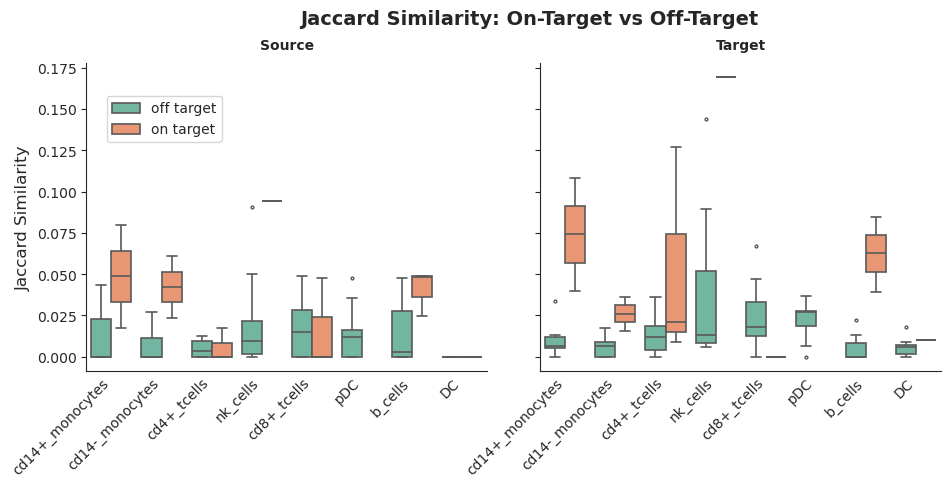

In [16]:
plot_jaccard_comparison(full_df)

In [ ]:
jaccard_data['database'] = 'cellmarker'
full_df['database'] = 'pangalaodn'
final_re  = pd.concat([jaccard_data, full_df])

In [ ]:
final_re.to_csv(op.join(analysis_output_dir, 'marker_gene_jaccard_overlaps.tsv'), sep = '\t')